<a href="https://colab.research.google.com/github/keerthana-25/rnn-colabs/blob/main/final_gnn_fundamentals_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🕸️ Graph Neural Networks: From Zero to Hero
## Part 1: Fundamentals - Understanding Graphs and Message Passing

---

**Welcome to the Graph Neural Networks Tutorial Series!**

This is **Part 1 of 3** in our progressive journey through Graph Neural Networks:

| Part | Notebook | Topics |
|------|----------|--------|
| **1** | **GNN Fundamentals (this notebook)** | Graphs, representations, message passing, GCN from scratch |
| 2 | Modern GNN Architectures | GraphSAGE, GAT, GIN, pooling, PyG |
| 3 | Advanced GNN Applications | Node/link/graph tasks, molecules, knowledge graphs |

---

## 📚 What You'll Learn

In this notebook, we'll build your understanding of GNNs from first principles:

1. **What are Graphs?** - Nodes, edges, and why graphs are everywhere
2. **Graph Representations** - Adjacency matrices, edge lists, and data structures
3. **Why GNNs?** - The limitations of traditional ML on graphs
4. **Message Passing Paradigm** - The core idea behind all GNNs
5. **GCN from Scratch** - Building Graph Convolutional Networks with NumPy
6. **GCN in PyTorch** - Transitioning to deep learning frameworks
7. **Hands-on Demo** - Node classification on a real dataset

---

## 🎯 Prerequisites

- Basic Python and NumPy
- Understanding of neural networks (see our Neural Networks tutorial series)
- Familiarity with PyTorch basics

Let's dive into the fascinating world of graphs! 🚀

In [1]:
# Install dependencies (uncomment for Colab)
# !pip install torch torch-geometric networkx matplotlib numpy scipy scikit-learn

In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Tuple, Optional, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"NetworkX version: {nx.__version__}")

✅ All imports successful!
NumPy version: 2.0.2
NetworkX version: 3.6.1


---

# Chapter 1: What Are Graphs? 🌐

---

## 1.1 Graphs Are Everywhere!

A **graph** is a mathematical structure that models relationships between objects.

```
        ┌─────────────────────────────────────────────────────────┐
        │                    GRAPH STRUCTURE                       │
        │                                                          │
        │      Node (Vertex)           Edge (Link)                 │
        │          ●─────────────────────●                         │
        │         /│\                   /│\                        │
        │        / │ \                 / │ \                       │
        │       ●  │  ●               ●  │  ●                      │
        │          │                     │                         │
        │      Features              Relationships                 │
        │    (attributes)           (connections)                  │
        └─────────────────────────────────────────────────────────┘
```

### Real-World Graph Examples

| Domain | Nodes | Edges | Example Task |
|--------|-------|-------|-------------|
| **Social Networks** | Users | Friendships | Friend recommendation |
| **Molecules** | Atoms | Chemical bonds | Drug discovery |
| **Citation Networks** | Papers | Citations | Paper classification |
| **Knowledge Graphs** | Entities | Relations | Question answering |
| **Transportation** | Locations | Roads | Route optimization |
| **Protein Structures** | Amino acids | Interactions | Function prediction |
| **Computer Networks** | Devices | Connections | Anomaly detection |
| **Recommender Systems** | Users + Items | Interactions | Product recommendation |

## 1.2 Formal Definition

A graph $G$ is defined as:

$$G = (V, E)$$

Where:
- $V = \{v_1, v_2, ..., v_n\}$ is the set of **nodes** (vertices)
- $E \subseteq V \times V$ is the set of **edges** (links)

An edge $(v_i, v_j) \in E$ connects node $v_i$ to node $v_j$.

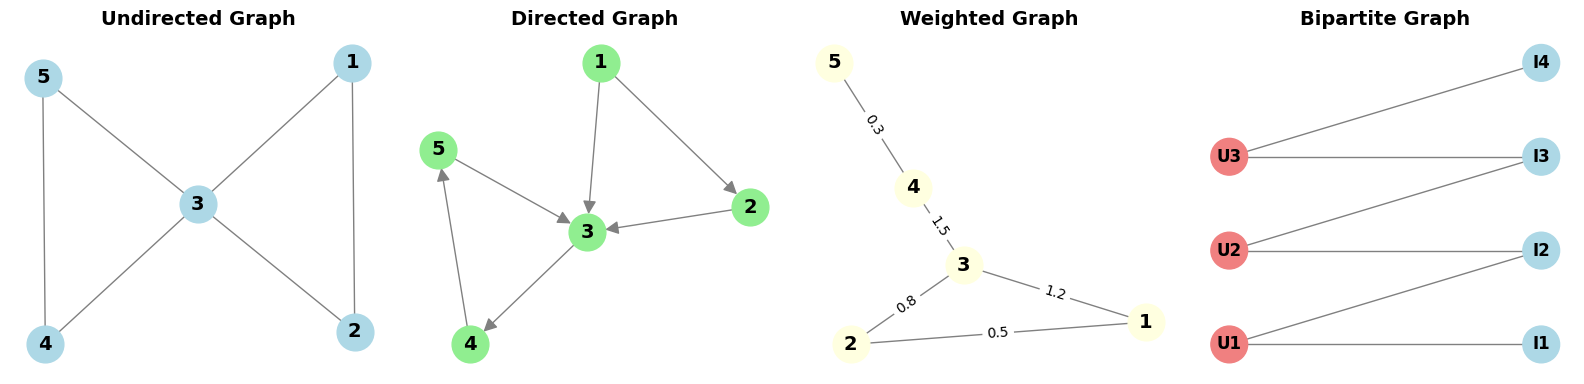

In [3]:
def visualize_graph_example():
    """Visualize different types of graphs."""

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # 1. Simple undirected graph
    G1 = nx.Graph()
    G1.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (5, 3)])
    pos1 = nx.spring_layout(G1, seed=42)
    nx.draw(G1, pos1, ax=axes[0], with_labels=True, node_color='lightblue',
            node_size=700, font_size=14, font_weight='bold', edge_color='gray')
    axes[0].set_title('Undirected Graph', fontsize=14, fontweight='bold')

    # 2. Directed graph
    G2 = nx.DiGraph()
    G2.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (5, 3)])
    pos2 = nx.spring_layout(G2, seed=42)
    nx.draw(G2, pos2, ax=axes[1], with_labels=True, node_color='lightgreen',
            node_size=700, font_size=14, font_weight='bold', edge_color='gray',
            arrows=True, arrowsize=20)
    axes[1].set_title('Directed Graph', fontsize=14, fontweight='bold')

    # 3. Weighted graph
    G3 = nx.Graph()
    G3.add_weighted_edges_from([(1, 2, 0.5), (1, 3, 1.2), (2, 3, 0.8),
                                 (3, 4, 1.5), (4, 5, 0.3)])
    pos3 = nx.spring_layout(G3, seed=42)
    nx.draw(G3, pos3, ax=axes[2], with_labels=True, node_color='lightyellow',
            node_size=700, font_size=14, font_weight='bold', edge_color='gray')
    edge_labels = nx.get_edge_attributes(G3, 'weight')
    nx.draw_networkx_edge_labels(G3, pos3, edge_labels, ax=axes[2], font_size=10)
    axes[2].set_title('Weighted Graph', fontsize=14, fontweight='bold')

    # 4. Bipartite graph (like user-item)
    G4 = nx.Graph()
    users = ['U1', 'U2', 'U3']
    items = ['I1', 'I2', 'I3', 'I4']
    G4.add_nodes_from(users, bipartite=0)
    G4.add_nodes_from(items, bipartite=1)
    G4.add_edges_from([('U1', 'I1'), ('U1', 'I2'), ('U2', 'I2'),
                       ('U2', 'I3'), ('U3', 'I3'), ('U3', 'I4')])
    pos4 = {}
    pos4.update((node, (0, i)) for i, node in enumerate(users))
    pos4.update((node, (1, i)) for i, node in enumerate(items))
    colors = ['lightcoral' if node in users else 'lightblue' for node in G4.nodes()]
    nx.draw(G4, pos4, ax=axes[3], with_labels=True, node_color=colors,
            node_size=700, font_size=12, font_weight='bold', edge_color='gray')
    axes[3].set_title('Bipartite Graph', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_graph_example()

## 1.3 Types of Graphs

```
┌─────────────────────────────────────────────────────────────────────┐
│                        GRAPH TAXONOMY                                │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  By Direction:          By Weights:           By Structure:          │
│  ┌──────────────┐       ┌──────────────┐     ┌──────────────┐       │
│  │ Undirected   │       │ Unweighted   │     │ Homogeneous  │       │
│  │   A ── B     │       │   A ── B     │     │ (same type   │       │
│  └──────────────┘       └──────────────┘     │  nodes/edges)│       │
│  ┌──────────────┐       ┌──────────────┐     └──────────────┘       │
│  │ Directed     │       │ Weighted     │     ┌──────────────┐       │
│  │   A ──► B    │       │   A ─0.5─ B  │     │ Heterogeneous│       │
│  └──────────────┘       └──────────────┘     │ (multiple    │       │
│                                              │  types)      │       │
│  Special Types:                              └──────────────┘       │
│  ┌──────────────┐   ┌──────────────┐   ┌──────────────┐            │
│  │ Cyclic       │   │ Acyclic (DAG)│   │ Bipartite    │            │
│  │  A→B→C→A     │   │  A→B→C       │   │ Users─Items  │            │
│  └──────────────┘   └──────────────┘   └──────────────┘            │
│                                                                      │
└─────────────────────────────────────────────────────────────────────┘
```

---

# Chapter 2: Graph Representations 📊

---

How do we represent graphs in code? There are several common representations:

## 2.1 Adjacency Matrix

An **adjacency matrix** $A$ is an $n \times n$ matrix where:

$$A_{ij} = \begin{cases} 1 & \text{if edge } (v_i, v_j) \in E \\ 0 & \text{otherwise} \end{cases}$$

```
    Graph:                 Adjacency Matrix:
                           
      1 ─── 2                   1  2  3  4
      │\    │               1 [ 0  1  1  0 ]
      │ \   │               2 [ 1  0  1  0 ]
      │  \  │               3 [ 1  1  0  1 ]
      3 ─── 4               4 [ 0  0  1  0 ]
```

**Properties:**
- For undirected graphs: $A = A^T$ (symmetric)
- For weighted graphs: $A_{ij}$ = weight of edge
- Diagonal entries $A_{ii}$: self-loops

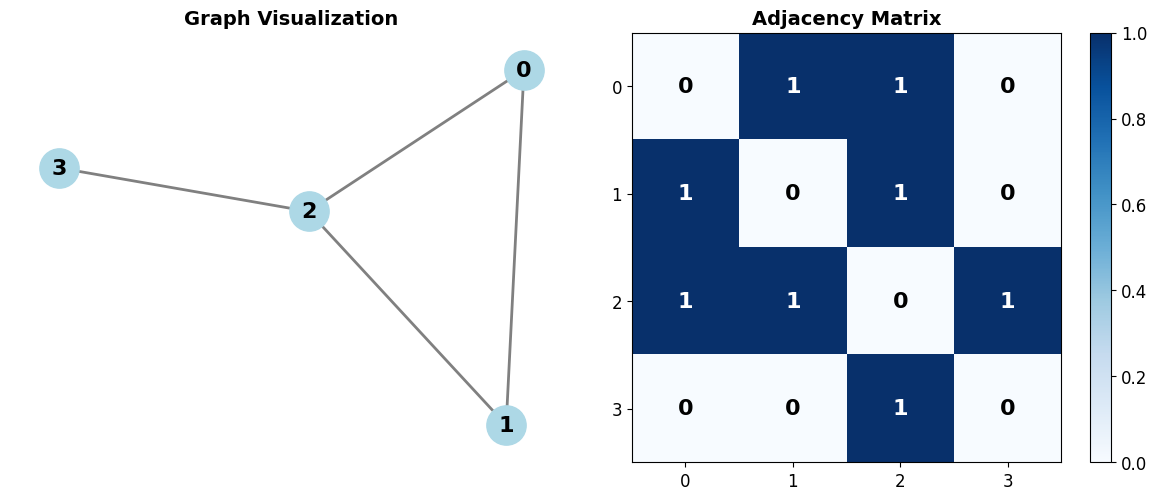

Adjacency Matrix:
[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]

Matrix is symmetric: True


In [4]:
def demonstrate_adjacency_matrix():
    """Demonstrate adjacency matrix representation."""

    # Create a simple graph
    G = nx.Graph()
    G.add_edges_from([(0, 1), (0, 2), (1, 2), (2, 3)])

    # Get adjacency matrix
    A = nx.adjacency_matrix(G).toarray()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Draw graph
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=axes[0], with_labels=True, node_color='lightblue',
            node_size=800, font_size=16, font_weight='bold', edge_color='gray',
            width=2)
    axes[0].set_title('Graph Visualization', fontsize=14, fontweight='bold')

    # Draw adjacency matrix
    im = axes[1].imshow(A, cmap='Blues')
    axes[1].set_xticks(range(4))
    axes[1].set_yticks(range(4))
    axes[1].set_xticklabels(['0', '1', '2', '3'])
    axes[1].set_yticklabels(['0', '1', '2', '3'])
    axes[1].set_title('Adjacency Matrix', fontsize=14, fontweight='bold')

    # Add values to matrix
    for i in range(4):
        for j in range(4):
            axes[1].text(j, i, str(A[i, j]), ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if A[i, j] > 0.5 else 'black')

    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

    print("Adjacency Matrix:")
    print(A)
    print(f"\nMatrix is symmetric: {np.allclose(A, A.T)}")

demonstrate_adjacency_matrix()

## 2.2 Edge List

An **edge list** is simply a list of tuples representing edges:

```python
edge_list = [(0, 1), (0, 2), (1, 2), (2, 3)]
```

**Pros:** Memory efficient for sparse graphs  
**Cons:** Slow neighbor lookup

## 2.3 Adjacency List

An **adjacency list** maps each node to its neighbors:

```python
adj_list = {
    0: [1, 2],
    1: [0, 2],
    2: [0, 1, 3],
    3: [2]
}
```

**Pros:** Fast neighbor lookup  
**Cons:** More complex structure

## 2.4 COO Format (Coordinate Format)

Used by PyTorch Geometric - two arrays for source and target nodes:

```python
edge_index = [[0, 0, 1, 1, 2, 2, 2, 3],   # source nodes
              [1, 2, 0, 2, 0, 1, 3, 2]]   # target nodes
```

In [5]:
def compare_representations():
    """Compare different graph representations."""

    # Define a graph
    edges = [(0, 1), (0, 2), (1, 2), (2, 3)]
    n_nodes = 4

    print("="*60)
    print("GRAPH REPRESENTATIONS COMPARISON")
    print("="*60)

    # 1. Edge List
    print("\n📋 1. EDGE LIST:")
    print(f"   {edges}")

    # 2. Adjacency Matrix
    print("\n📊 2. ADJACENCY MATRIX:")
    adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)
    for i, j in edges:
        adj_matrix[i, j] = 1
        adj_matrix[j, i] = 1  # undirected
    print(adj_matrix)

    # 3. Adjacency List
    print("\n📝 3. ADJACENCY LIST:")
    adj_list = {i: [] for i in range(n_nodes)}
    for i, j in edges:
        adj_list[i].append(j)
        adj_list[j].append(i)  # undirected
    for node, neighbors in adj_list.items():
        print(f"   Node {node}: {neighbors}")

    # 4. COO Format (PyTorch Geometric style)
    print("\n🔢 4. COO FORMAT (edge_index):")
    # For undirected graphs, we include both directions
    src = []
    dst = []
    for i, j in edges:
        src.extend([i, j])
        dst.extend([j, i])
    edge_index = np.array([src, dst])
    print(f"   Source:  {edge_index[0]}")
    print(f"   Target:  {edge_index[1]}")

    # Memory comparison
    print("\n💾 MEMORY COMPARISON (for sparse graphs):")
    print(f"   Adjacency Matrix: O(n²) = O({n_nodes}²) = {n_nodes**2} elements")
    print(f"   Edge List:        O(E) = O({len(edges)}) = {len(edges)} tuples")
    print(f"   COO Format:       O(2E) = O({2*len(edges)*2}) = {2*len(edges)*2} integers")

compare_representations()

GRAPH REPRESENTATIONS COMPARISON

📋 1. EDGE LIST:
   [(0, 1), (0, 2), (1, 2), (2, 3)]

📊 2. ADJACENCY MATRIX:
[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]

📝 3. ADJACENCY LIST:
   Node 0: [1, 2]
   Node 1: [0, 2]
   Node 2: [0, 1, 3]
   Node 3: [2]

🔢 4. COO FORMAT (edge_index):
   Source:  [0 1 0 2 1 2 2 3]
   Target:  [1 0 2 0 2 1 3 2]

💾 MEMORY COMPARISON (for sparse graphs):
   Adjacency Matrix: O(n²) = O(4²) = 16 elements
   Edge List:        O(E) = O(4) = 4 tuples
   COO Format:       O(2E) = O(16) = 16 integers


## 2.5 Node Features

In GNNs, nodes often have **feature vectors** (attributes):

```
    Node Features Matrix X ∈ ℝⁿˣᵈ
    
    n = number of nodes
    d = feature dimension
    
            Feature 1  Feature 2  Feature 3  ...  Feature d
    Node 0  [  0.5       1.2        0.3      ...    0.8    ]
    Node 1  [  0.1       0.9        0.7      ...    0.2    ]
    Node 2  [  0.8       0.4        0.1      ...    0.5    ]
    ...     [  ...       ...        ...      ...    ...    ]
    Node n  [  0.3       0.7        0.9      ...    0.1    ]
```

**Examples of node features:**
- Social networks: user profile (age, interests, location)
- Molecules: atom properties (atomic number, charge, hybridization)
- Citation networks: paper embeddings (bag-of-words, word2vec)

In [6]:
class Graph:
    """Simple graph class with node features."""

    def __init__(self, num_nodes: int, edges: List[Tuple[int, int]],
                 node_features: Optional[np.ndarray] = None):
        """
        Initialize graph.

        Args:
            num_nodes: Number of nodes
            edges: List of (source, target) tuples
            node_features: Node feature matrix [num_nodes, feature_dim]
        """
        self.num_nodes = num_nodes
        self.edges = edges
        self.num_edges = len(edges)

        # Build adjacency matrix
        self.adj_matrix = np.zeros((num_nodes, num_nodes))
        for i, j in edges:
            self.adj_matrix[i, j] = 1
            self.adj_matrix[j, i] = 1  # undirected

        # Node features
        if node_features is not None:
            self.X = node_features
        else:
            # Default: one-hot encoding
            self.X = np.eye(num_nodes)

        self.feature_dim = self.X.shape[1]

        # Build adjacency list
        self.adj_list = {i: [] for i in range(num_nodes)}
        for i, j in edges:
            self.adj_list[i].append(j)
            self.adj_list[j].append(i)

    def get_neighbors(self, node: int) -> List[int]:
        """Get neighbors of a node."""
        return self.adj_list[node]

    def degree(self, node: int) -> int:
        """Get degree of a node."""
        return len(self.adj_list[node])

    def degree_matrix(self) -> np.ndarray:
        """Get diagonal degree matrix."""
        degrees = np.sum(self.adj_matrix, axis=1)
        return np.diag(degrees)

    def __repr__(self):
        return f"Graph(nodes={self.num_nodes}, edges={self.num_edges}, features={self.feature_dim})"


# Create example graph
edges = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (4, 5), (3, 5)]
node_features = np.random.randn(6, 4)  # 6 nodes, 4 features each

graph = Graph(num_nodes=6, edges=edges, node_features=node_features)

print(graph)
print(f"\nAdjacency Matrix:")
print(graph.adj_matrix)
print(f"\nNode Features (first 2 rows):")
print(graph.X[:2])
print(f"\nNeighbors of node 2: {graph.get_neighbors(2)}")
print(f"Degree of node 2: {graph.degree(2)}")

Graph(nodes=6, edges=7, features=4)

Adjacency Matrix:
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0.]]

Node Features (first 2 rows):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]]

Neighbors of node 2: [0, 1, 3]
Degree of node 2: 3


---

# Chapter 3: Why Do We Need GNNs? 🤔

---

## 3.1 The Problem with Traditional ML on Graphs

Traditional machine learning methods face challenges with graph data:

```
┌─────────────────────────────────────────────────────────────────────┐
│                    CHALLENGES WITH GRAPHS                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  1. VARIABLE SIZE                                                    │
│     ┌───┐  vs  ┌───────────────┐                                    │
│     │●─●│      │●─●─●─●─●─●─●─●│   Different graphs have            │
│     └───┘      └───────────────┘   different numbers of nodes       │
│                                                                      │
│  2. NO CANONICAL ORDERING                                            │
│     ┌─────┐      ┌─────┐                                            │
│     │1─2─3│  =?  │2─3─1│   Same graph, different node labels!       │
│     └─────┘      └─────┘                                            │
│                                                                      │
│  3. PERMUTATION INVARIANCE                                           │
│     f(πG) = f(G)  for any permutation π                             │
│     Output should not depend on node ordering                        │
│                                                                      │
│  4. LOCALITY + GLOBAL STRUCTURE                                      │
│     Need to capture both local neighborhoods and                     │
│     global graph patterns                                            │
│                                                                      │
└─────────────────────────────────────────────────────────────────────┘
```

## 3.2 Why Not Just Flatten the Adjacency Matrix?

You might think: "Can't we just flatten the adjacency matrix into a vector?"

**Problems:**
1. $O(n^2)$ input size - doesn't scale
2. Not permutation invariant - reordering nodes changes the input
3. Loses structural information
4. Can't handle variable-sized graphs

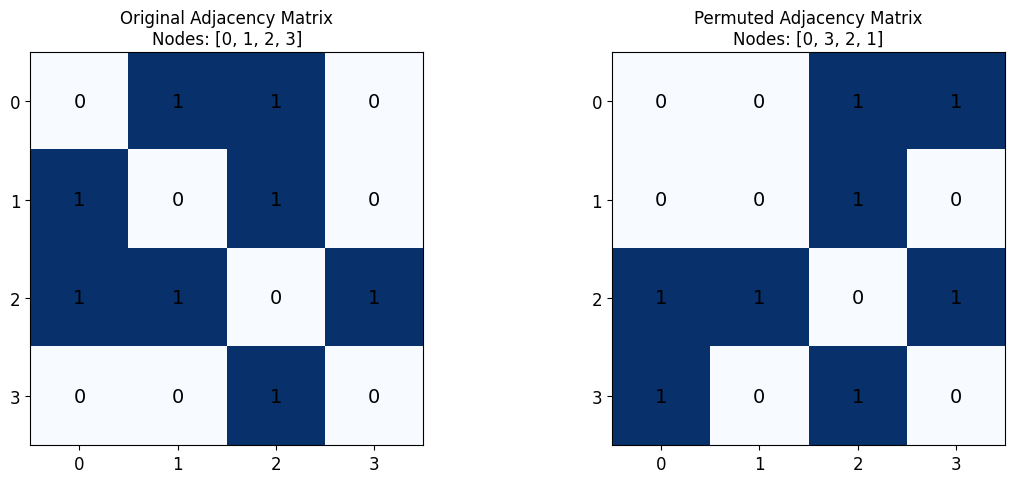

🔑 KEY INSIGHT:
   Both matrices represent THE SAME GRAPH!
   But flattened vectors are different:
   Original: [0 1 1 0 1 0 1 0]...
   Permuted: [0 0 1 1 0 0 1 0]...

   A good graph model should give the SAME output for both!


In [7]:
def demonstrate_permutation_problem():
    """Show why node ordering matters for naive approaches."""

    # Same graph structure, different node orderings
    # Original: 0-1-2 triangle with 2-3 edge
    # Permuted: swap nodes 1 and 3

    # Original adjacency matrix
    A_original = np.array([
        [0, 1, 1, 0],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [0, 0, 1, 0]
    ])

    # Permutation: swap nodes 1 and 3
    P = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0]
    ])

    # Permuted adjacency matrix: P @ A @ P^T
    A_permuted = P @ A_original @ P.T

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original
    im1 = axes[0].imshow(A_original, cmap='Blues')
    axes[0].set_title('Original Adjacency Matrix\nNodes: [0, 1, 2, 3]', fontsize=12)
    axes[0].set_xticks(range(4))
    axes[0].set_yticks(range(4))
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, str(int(A_original[i, j])), ha='center', va='center', fontsize=14)

    # Permuted
    im2 = axes[1].imshow(A_permuted, cmap='Blues')
    axes[1].set_title('Permuted Adjacency Matrix\nNodes: [0, 3, 2, 1]', fontsize=12)
    axes[1].set_xticks(range(4))
    axes[1].set_yticks(range(4))
    for i in range(4):
        for j in range(4):
            axes[1].text(j, i, str(int(A_permuted[i, j])), ha='center', va='center', fontsize=14)

    plt.tight_layout()
    plt.show()

    print("🔑 KEY INSIGHT:")
    print("   Both matrices represent THE SAME GRAPH!")
    print(f"   But flattened vectors are different:")
    print(f"   Original: {A_original.flatten()[:8]}...")
    print(f"   Permuted: {A_permuted.flatten()[:8]}...")
    print("\n   A good graph model should give the SAME output for both!")

demonstrate_permutation_problem()

## 3.3 The Solution: Graph Neural Networks

GNNs are designed to be:

| Property | Description | How GNNs Achieve It |
|----------|-------------|--------------------|
| **Permutation Invariant** | Output doesn't depend on node ordering | Symmetric aggregation functions (sum, mean, max) |
| **Local + Global** | Capture both local and global structure | Multiple layers = larger receptive field |
| **Inductive** | Can generalize to unseen graphs | Learn transferable patterns |
| **Scalable** | Handle large graphs | Sparse operations, sampling |

---

# Chapter 4: The Message Passing Paradigm 📬

---

## 4.1 The Core Idea

The fundamental idea behind most GNNs is **message passing** (also called neighborhood aggregation):

```
┌─────────────────────────────────────────────────────────────────────┐
│                    MESSAGE PASSING FRAMEWORK                         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  For each node v, in each layer:                                     │
│                                                                      │
│  1. AGGREGATE: Collect messages from neighbors                       │
│                                                                      │
│         ●───────●                   m_v = AGGREGATE({h_u : u ∈ N(v)})│
│        /│\      │                                                    │
│       / │ \     │   Messages                                        │
│      ●  ●  ●    ▼   flow to v                                       │
│         │                                                            │
│         ●  (v)                                                       │
│                                                                      │
│  2. UPDATE: Combine with own features                                │
│                                                                      │
│         h_v^(l+1) = UPDATE(h_v^(l), m_v)                             │
│                                                                      │
│  3. REPEAT for L layers                                              │
│                                                                      │
│         After L layers, node v has information from                  │
│         all nodes within L hops                                      │
│                                                                      │
└─────────────────────────────────────────────────────────────────────┘
```

## 4.2 Mathematical Formulation

In layer $l$, for node $v$:

$$h_v^{(l+1)} = \text{UPDATE}^{(l)}\left( h_v^{(l)}, \text{AGGREGATE}^{(l)}\left( \{ h_u^{(l)} : u \in \mathcal{N}(v) \} \right) \right)$$

Where:
- $h_v^{(l)}$ = hidden state of node $v$ at layer $l$
- $\mathcal{N}(v)$ = neighbors of node $v$
- $h_v^{(0)} = x_v$ (initial node features)

Common **AGGREGATE** functions:
- **Sum**: $\sum_{u \in \mathcal{N}(v)} h_u$
- **Mean**: $\frac{1}{|\mathcal{N}(v)|} \sum_{u \in \mathcal{N}(v)} h_u$
- **Max**: $\max_{u \in \mathcal{N}(v)} h_u$

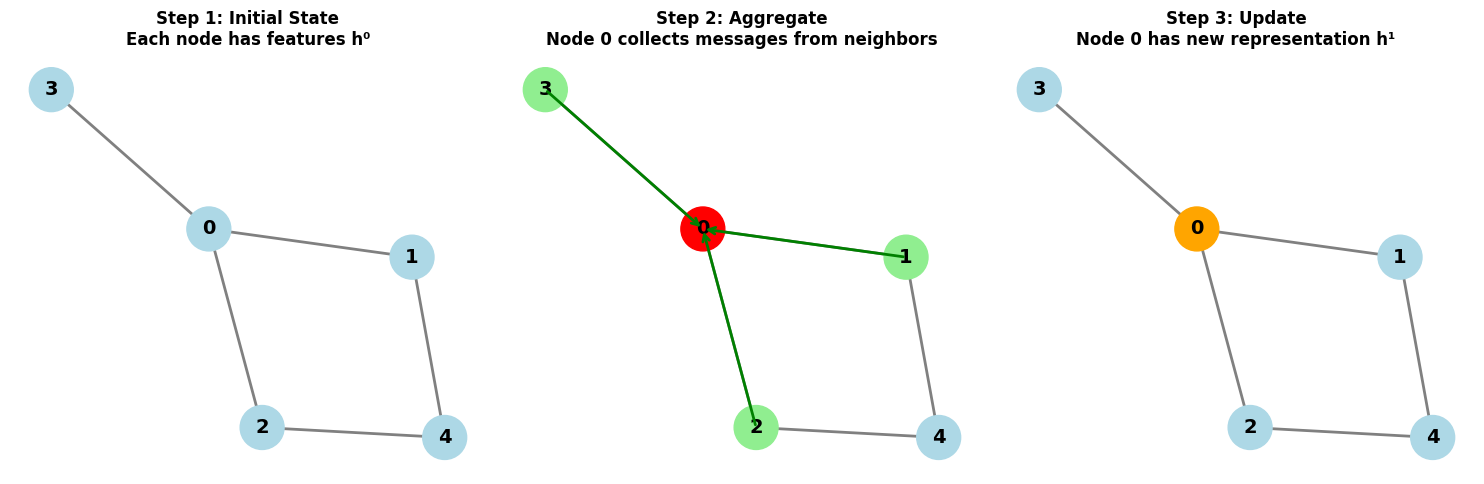

In [8]:
def visualize_message_passing():
    """Visualize message passing for one node."""

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Create a small graph
    G = nx.Graph()
    G.add_edges_from([(0, 1), (0, 2), (0, 3), (1, 4), (2, 4)])
    pos = nx.spring_layout(G, seed=42)

    # Step 1: Initial state
    node_colors = ['lightblue'] * 5
    nx.draw(G, pos, ax=axes[0], with_labels=True, node_color=node_colors,
            node_size=1000, font_size=14, font_weight='bold', edge_color='gray', width=2)
    axes[0].set_title('Step 1: Initial State\nEach node has features h⁰', fontsize=12, fontweight='bold')

    # Step 2: Message passing to node 0
    node_colors = ['red', 'lightgreen', 'lightgreen', 'lightgreen', 'lightblue']
    nx.draw(G, pos, ax=axes[1], with_labels=True, node_color=node_colors,
            node_size=1000, font_size=14, font_weight='bold', edge_color='gray', width=2)
    # Draw arrows from neighbors to node 0
    for neighbor in [1, 2, 3]:
        axes[1].annotate('', xy=pos[0], xytext=pos[neighbor],
                        arrowprops=dict(arrowstyle='->', color='green', lw=2))
    axes[1].set_title('Step 2: Aggregate\nNode 0 collects messages from neighbors', fontsize=12, fontweight='bold')

    # Step 3: Update
    node_colors = ['orange', 'lightblue', 'lightblue', 'lightblue', 'lightblue']
    nx.draw(G, pos, ax=axes[2], with_labels=True, node_color=node_colors,
            node_size=1000, font_size=14, font_weight='bold', edge_color='gray', width=2)
    axes[2].set_title('Step 3: Update\nNode 0 has new representation h¹', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_message_passing()

## 4.3 Receptive Field Growth

With each layer, a node's receptive field grows:

```
    Layer 0:        Layer 1:         Layer 2:
    (just self)     (1-hop)          (2-hop)
    
                                         ○
                        ●               /
         ●             /●\            ●─●
                      ● ● ●          /●\ │
                                    ● ● ●─●
    
    Node sees:      Node sees:       Node sees:
    itself          neighbors        neighbors of
                                     neighbors
```

After $L$ layers, each node has aggregated information from all nodes within $L$ hops.

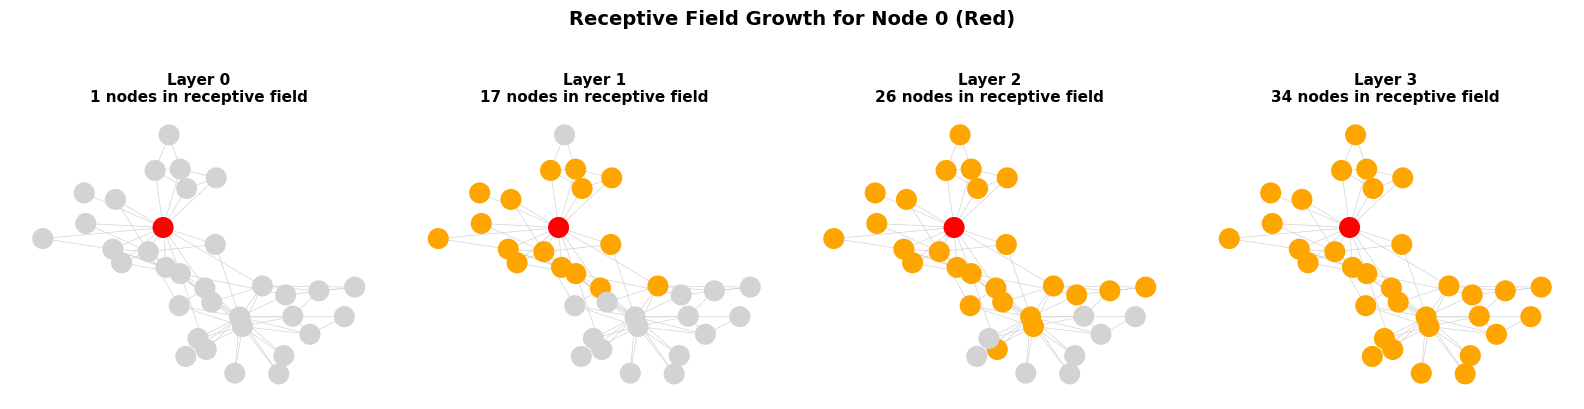

In [9]:
def visualize_receptive_field():
    """Visualize how receptive field grows with layers."""

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Create a larger graph
    G = nx.karate_club_graph()  # Famous social network
    pos = nx.spring_layout(G, seed=42)

    target_node = 0

    for layer, ax in enumerate(axes):
        if layer == 0:
            # Just the target node
            reachable = {target_node}
        else:
            # Nodes within 'layer' hops
            reachable = set(nx.single_source_shortest_path_length(G, target_node, cutoff=layer).keys())

        colors = ['red' if n == target_node else
                  'orange' if n in reachable else
                  'lightgray' for n in G.nodes()]

        nx.draw(G, pos, ax=ax, node_color=colors, node_size=200,
                with_labels=False, edge_color='lightgray', width=0.5)

        ax.set_title(f'Layer {layer}\n{len(reachable)} nodes in receptive field',
                    fontsize=11, fontweight='bold')

    plt.suptitle('Receptive Field Growth for Node 0 (Red)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_receptive_field()

## 4.4 Simple Message Passing Implementation

In [10]:
def simple_message_passing(graph: Graph, aggregation: str = 'mean') -> np.ndarray:
    """
    Simple message passing without learnable parameters.

    Args:
        graph: Input graph with node features
        aggregation: 'mean', 'sum', or 'max'

    Returns:
        Updated node features
    """
    X = graph.X
    A = graph.adj_matrix
    n = graph.num_nodes

    # Output features
    X_new = np.zeros_like(X)

    for v in range(n):
        neighbors = graph.get_neighbors(v)

        if len(neighbors) == 0:
            # No neighbors, keep own features
            X_new[v] = X[v]
        else:
            # Aggregate neighbor features
            neighbor_features = X[neighbors]

            if aggregation == 'mean':
                aggregated = np.mean(neighbor_features, axis=0)
            elif aggregation == 'sum':
                aggregated = np.sum(neighbor_features, axis=0)
            elif aggregation == 'max':
                aggregated = np.max(neighbor_features, axis=0)
            else:
                raise ValueError(f"Unknown aggregation: {aggregation}")

            # Combine with own features (simple average)
            X_new[v] = 0.5 * X[v] + 0.5 * aggregated

    return X_new


# Test simple message passing
edges = [(0, 1), (0, 2), (1, 2), (2, 3)]
X = np.array([
    [1.0, 0.0],  # Node 0
    [0.0, 1.0],  # Node 1
    [0.5, 0.5],  # Node 2
    [1.0, 1.0],  # Node 3
])

graph = Graph(num_nodes=4, edges=edges, node_features=X)

print("Original node features:")
print(X)

X_updated = simple_message_passing(graph, aggregation='mean')
print("\nAfter 1 round of message passing (mean):")
print(X_updated)

# Apply multiple rounds
print("\nAfter 3 rounds of message passing:")
X_multi = X.copy()
for i in range(3):
    temp_graph = Graph(num_nodes=4, edges=edges, node_features=X_multi)
    X_multi = simple_message_passing(temp_graph, aggregation='mean')
print(X_multi)
print("\n💡 Notice: Features become more similar as information propagates!")

Original node features:
[[1.  0. ]
 [0.  1. ]
 [0.5 0.5]
 [1.  1. ]]

After 1 round of message passing (mean):
[[0.625      0.375     ]
 [0.375      0.625     ]
 [0.58333333 0.58333333]
 [0.75       0.75      ]]

After 3 rounds of message passing:
[[0.54427083 0.52864583]
 [0.52864583 0.54427083]
 [0.57638889 0.57638889]
 [0.625      0.625     ]]

💡 Notice: Features become more similar as information propagates!


---

# Chapter 5: Graph Convolutional Networks (GCN) from Scratch 🧮

---

## 5.1 GCN Overview

**Graph Convolutional Networks** (Kipf & Welling, 2017) are one of the most influential GNN architectures.

The key equation for a GCN layer:

$$H^{(l+1)} = \sigma\left( \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)} \right)$$

Where:
- $\tilde{A} = A + I$ (adjacency with self-loops)
- $\tilde{D}$ = degree matrix of $\tilde{A}$
- $H^{(l)}$ = node features at layer $l$
- $W^{(l)}$ = learnable weight matrix
- $\sigma$ = activation function (e.g., ReLU)

```
┌─────────────────────────────────────────────────────────────────────┐
│                        GCN LAYER BREAKDOWN                           │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  Step 1: Add self-loops                                              │
│          Ã = A + I                                                   │
│          (Each node is also its own neighbor)                        │
│                                                                      │
│  Step 2: Symmetric normalization                                     │
│          D̃⁻¹/² Ã D̃⁻¹/²                                              │
│          (Normalize by degrees to prevent exploding activations)     │
│                                                                      │
│  Step 3: Feature transformation                                      │
│          H W                                                         │
│          (Linear projection)                                         │
│                                                                      │
│  Step 4: Neighborhood aggregation                                    │
│          (D̃⁻¹/² Ã D̃⁻¹/²) (H W)                                      │
│          (Aggregate transformed features)                            │
│                                                                      │
│  Step 5: Non-linearity                                               │
│          σ(...)                                                      │
│          (Apply activation function)                                 │
│                                                                      │
└─────────────────────────────────────────────────────────────────────┘
```

## 5.2 Understanding the Normalization

Why do we use $\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$?

Consider a node with many neighbors. Without normalization:
- Sum aggregation would give huge values
- Features would explode through layers

The symmetric normalization:
$$\hat{A}_{ij} = \frac{\tilde{A}_{ij}}{\sqrt{\tilde{d}_i} \sqrt{\tilde{d}_j}}$$

This ensures:
- Features are normalized by both source and target degrees
- Spectral properties are preserved
- Avoids exploding/vanishing gradients

In [11]:
def compute_normalized_adjacency(A: np.ndarray) -> np.ndarray:
    """
    Compute the normalized adjacency matrix for GCN.

    Â = D̃^(-1/2) @ Ã @ D̃^(-1/2)

    where Ã = A + I (add self-loops)
    """
    n = A.shape[0]

    # Step 1: Add self-loops
    A_tilde = A + np.eye(n)

    # Step 2: Compute degree matrix
    D_tilde = np.diag(np.sum(A_tilde, axis=1))

    # Step 3: Compute D^(-1/2)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde) + 1e-8))

    # Step 4: Symmetric normalization
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

    return A_hat


# Demonstrate normalization
A = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [0, 0, 1, 0]
], dtype=float)

A_hat = compute_normalized_adjacency(A)

print("Original Adjacency Matrix A:")
print(A)
print("\nNormalized Adjacency Matrix Â:")
print(np.round(A_hat, 3))
print("\n💡 Notice:")
print("   - Diagonal entries are non-zero (self-loops)")
print("   - Row sums are close to 1 (normalized)")
print(f"   - Row sums: {np.round(A_hat.sum(axis=1), 3)}")

Original Adjacency Matrix A:
[[0. 1. 1. 0.]
 [1. 0. 1. 0.]
 [1. 1. 0. 1.]
 [0. 0. 1. 0.]]

Normalized Adjacency Matrix Â:
[[0.333 0.333 0.289 0.   ]
 [0.333 0.333 0.289 0.   ]
 [0.289 0.289 0.25  0.354]
 [0.    0.    0.354 0.5  ]]

💡 Notice:
   - Diagonal entries are non-zero (self-loops)
   - Row sums are close to 1 (normalized)
   - Row sums: [0.955 0.955 1.181 0.854]


## 5.3 GCN Layer Implementation (NumPy)

In [12]:
class GCNLayerNumPy:
    """
    Graph Convolutional Layer implemented in NumPy.

    H' = σ(Â @ H @ W + b)

    where Â is the normalized adjacency matrix.
    """

    def __init__(self, in_features: int, out_features: int,
                 activation: str = 'relu'):
        """
        Initialize GCN layer.

        Args:
            in_features: Input feature dimension
            out_features: Output feature dimension
            activation: Activation function ('relu', 'tanh', 'none')
        """
        self.in_features = in_features
        self.out_features = out_features
        self.activation = activation

        # Initialize weights (He initialization)
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features)

        # Cache for backprop
        self.cache = {}

    def forward(self, H: np.ndarray, A_hat: np.ndarray) -> np.ndarray:
        """
        Forward pass.

        Args:
            H: Node features [num_nodes, in_features]
            A_hat: Normalized adjacency matrix [num_nodes, num_nodes]

        Returns:
            Updated node features [num_nodes, out_features]
        """
        # Step 1: Neighborhood aggregation
        # Aggregate features from neighbors (including self)
        aggregated = A_hat @ H  # [num_nodes, in_features]

        # Step 2: Linear transformation
        Z = aggregated @ self.W + self.b  # [num_nodes, out_features]

        # Step 3: Activation
        if self.activation == 'relu':
            H_out = np.maximum(0, Z)
        elif self.activation == 'tanh':
            H_out = np.tanh(Z)
        else:  # 'none' or linear
            H_out = Z

        # Cache for backprop
        self.cache = {
            'H': H,
            'A_hat': A_hat,
            'aggregated': aggregated,
            'Z': Z,
            'H_out': H_out
        }

        return H_out

    def backward(self, dH_out: np.ndarray, learning_rate: float = 0.01):
        """
        Backward pass.

        Args:
            dH_out: Gradient w.r.t. output [num_nodes, out_features]
            learning_rate: Learning rate for weight update

        Returns:
            dH: Gradient w.r.t. input [num_nodes, in_features]
        """
        H = self.cache['H']
        A_hat = self.cache['A_hat']
        aggregated = self.cache['aggregated']
        Z = self.cache['Z']

        # Gradient through activation
        if self.activation == 'relu':
            dZ = dH_out * (Z > 0)
        elif self.activation == 'tanh':
            dZ = dH_out * (1 - np.tanh(Z)**2)
        else:
            dZ = dH_out

        # Gradient of weights
        dW = aggregated.T @ dZ
        db = np.sum(dZ, axis=0)

        # Gradient of input
        d_aggregated = dZ @ self.W.T
        dH = A_hat.T @ d_aggregated

        # Update weights
        self.W -= learning_rate * dW
        self.b -= learning_rate * db

        return dH

    def __repr__(self):
        return f"GCNLayer({self.in_features} -> {self.out_features}, {self.activation})"


# Test GCN layer
layer = GCNLayerNumPy(in_features=4, out_features=2, activation='relu')
print(layer)

# Create test data
H = np.random.randn(4, 4)  # 4 nodes, 4 features each
A = np.array([[0, 1, 1, 0], [1, 0, 1, 0], [1, 1, 0, 1], [0, 0, 1, 0]], dtype=float)
A_hat = compute_normalized_adjacency(A)

# Forward pass
H_out = layer.forward(H, A_hat)
print(f"\nInput shape: {H.shape}")
print(f"Output shape: {H_out.shape}")
print(f"\nOutput:")
print(np.round(H_out, 3))

GCNLayer(4 -> 2, relu)

Input shape: (4, 4)
Output shape: (4, 2)

Output:
[[0.939 0.   ]
 [0.939 0.   ]
 [1.132 0.   ]
 [0.363 0.492]]


## 5.4 Full GCN Network (NumPy)

In [13]:
class GCNNumPy:
    """
    Graph Convolutional Network implemented in NumPy.
    """

    def __init__(self, layer_dims: List[int], activations: Optional[List[str]] = None):
        """
        Initialize GCN.

        Args:
            layer_dims: List of dimensions [input_dim, hidden1, hidden2, ..., output_dim]
            activations: List of activations for each layer (default: relu for hidden, none for output)
        """
        self.num_layers = len(layer_dims) - 1

        if activations is None:
            activations = ['relu'] * (self.num_layers - 1) + ['none']

        self.layers = []
        for i in range(self.num_layers):
            layer = GCNLayerNumPy(layer_dims[i], layer_dims[i+1], activations[i])
            self.layers.append(layer)

    def forward(self, X: np.ndarray, A_hat: np.ndarray) -> np.ndarray:
        """
        Forward pass through all layers.

        Args:
            X: Input node features [num_nodes, input_dim]
            A_hat: Normalized adjacency matrix

        Returns:
            Output node representations [num_nodes, output_dim]
        """
        H = X
        for layer in self.layers:
            H = layer.forward(H, A_hat)
        return H

    def backward(self, dL: np.ndarray, learning_rate: float = 0.01):
        """
        Backward pass through all layers.
        """
        dH = dL
        for layer in reversed(self.layers):
            dH = layer.backward(dH, learning_rate)

    def __repr__(self):
        return f"GCN(layers={[str(l) for l in self.layers]})"


def softmax(x: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


def cross_entropy_loss(y_pred: np.ndarray, y_true: np.ndarray) -> Tuple[float, np.ndarray]:
    """Cross-entropy loss with gradient."""
    probs = softmax(y_pred)
    n = y_true.shape[0]

    # One-hot encode if needed
    if y_true.ndim == 1:
        y_onehot = np.zeros_like(probs)
        y_onehot[np.arange(n), y_true] = 1
    else:
        y_onehot = y_true

    # Loss
    loss = -np.sum(y_onehot * np.log(probs + 1e-8)) / n

    # Gradient
    grad = (probs - y_onehot) / n

    return loss, grad


# Create and test GCN
gcn = GCNNumPy(layer_dims=[4, 8, 3])  # 4 input -> 8 hidden -> 3 output (classes)
print(gcn)

# Test forward pass
X = np.random.randn(4, 4)  # 4 nodes, 4 features
y = np.array([0, 1, 2, 1])  # Labels for 4 nodes
A = np.array([[0, 1, 1, 0], [1, 0, 1, 0], [1, 1, 0, 1], [0, 0, 1, 0]], dtype=float)
A_hat = compute_normalized_adjacency(A)

output = gcn.forward(X, A_hat)
print(f"\nOutput shape: {output.shape}")
print(f"Output (logits):")
print(np.round(output, 3))
print(f"\nPredicted classes: {np.argmax(output, axis=1)}")
print(f"True classes:      {y}")

GCN(layers=['GCNLayer(4 -> 8, relu)', 'GCNLayer(8 -> 3, none)'])

Output shape: (4, 3)
Output (logits):
[[ 0.1   -0.047  0.239]
 [ 0.1   -0.047  0.239]
 [ 0.064 -0.159  0.29 ]
 [-0.033 -0.248  0.178]]

Predicted classes: [2 2 2 2]
True classes:      [0 1 2 1]


## 5.5 Training the GCN (NumPy)

Epoch   0 | Loss: 1.3252 | Train Acc: 0.00 | Test Acc: 0.00
Epoch  50 | Loss: 0.3574 | Train Acc: 1.00 | Test Acc: 1.00
Epoch 100 | Loss: 0.1146 | Train Acc: 1.00 | Test Acc: 1.00
Epoch 150 | Loss: 0.0540 | Train Acc: 1.00 | Test Acc: 1.00


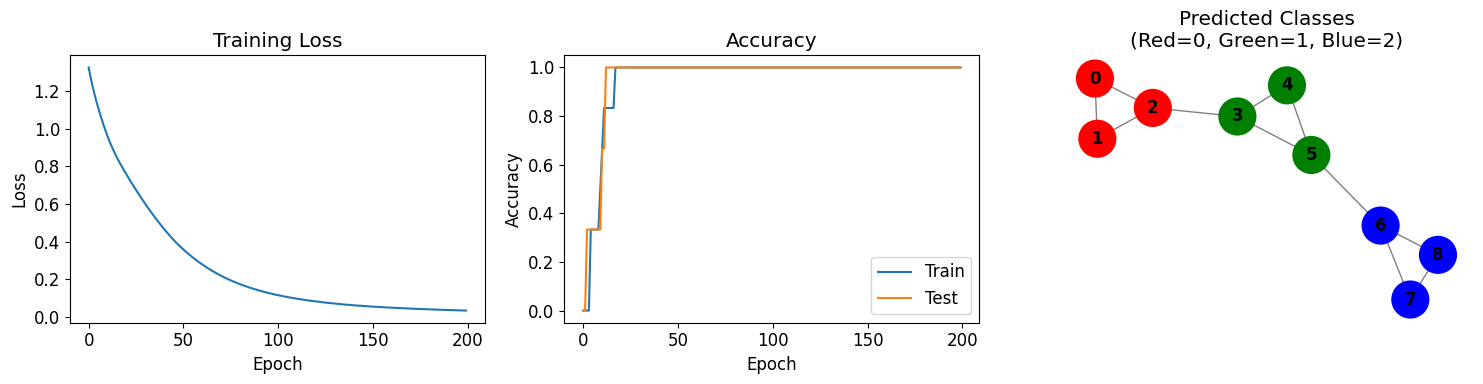


✅ Final Test Accuracy: 1.00
   Predictions: [0 0 0 1 1 1 2 2 2]
   True labels: [0 0 0 1 1 1 2 2 2]


In [14]:
def train_gcn_numpy():
    """
    Train GCN on a simple node classification task.
    """
    np.random.seed(42)

    # Create a simple graph with community structure
    # Community 1: nodes 0, 1, 2 (class 0)
    # Community 2: nodes 3, 4, 5 (class 1)
    # Community 3: nodes 6, 7, 8 (class 2)

    edges = [
        # Community 1
        (0, 1), (1, 2), (0, 2),
        # Community 2
        (3, 4), (4, 5), (3, 5),
        # Community 3
        (6, 7), (7, 8), (6, 8),
        # Cross-community edges
        (2, 3), (5, 6)
    ]

    n_nodes = 9
    n_features = 4
    n_classes = 3

    # Node features (random, but with some structure)
    X = np.random.randn(n_nodes, n_features) * 0.5
    # Add class-specific patterns
    X[0:3, 0] += 1  # Community 1
    X[3:6, 1] += 1  # Community 2
    X[6:9, 2] += 1  # Community 3

    # Labels
    y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])

    # Build adjacency matrix
    A = np.zeros((n_nodes, n_nodes))
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1

    A_hat = compute_normalized_adjacency(A)

    # Train/test split (simple: use nodes 0, 3, 6 for testing)
    train_mask = np.array([False, True, True, False, True, True, False, True, True])
    test_mask = ~train_mask

    # Create GCN
    gcn = GCNNumPy(layer_dims=[n_features, 16, n_classes])

    # Training
    losses = []
    train_accs = []
    test_accs = []

    for epoch in range(200):
        # Forward pass
        output = gcn.forward(X, A_hat)

        # Loss (only on training nodes)
        loss, grad = cross_entropy_loss(output[train_mask], y[train_mask])

        # Create full gradient (zeros for non-training nodes)
        full_grad = np.zeros_like(output)
        full_grad[train_mask] = grad

        # Backward pass
        gcn.backward(full_grad, learning_rate=0.1)

        # Metrics
        preds = np.argmax(output, axis=1)
        train_acc = np.mean(preds[train_mask] == y[train_mask])
        test_acc = np.mean(preds[test_mask] == y[test_mask])

        losses.append(loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 50 == 0:
            print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(losses)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')

    axes[1].plot(train_accs, label='Train')
    axes[1].plot(test_accs, label='Test')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    # Visualize final predictions
    G = nx.Graph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)

    final_output = gcn.forward(X, A_hat)
    final_preds = np.argmax(final_output, axis=1)

    colors = ['red', 'green', 'blue']
    node_colors = [colors[p] for p in final_preds]

    nx.draw(G, pos, ax=axes[2], node_color=node_colors, with_labels=True,
            node_size=700, font_size=12, font_weight='bold', edge_color='gray')
    axes[2].set_title('Predicted Classes\n(Red=0, Green=1, Blue=2)')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Final Test Accuracy: {test_accs[-1]:.2f}")
    print(f"   Predictions: {final_preds}")
    print(f"   True labels: {y}")

train_gcn_numpy()

---

# Chapter 6: GCN in PyTorch 🔥

---

Now let's implement the same GCN using PyTorch for automatic differentiation and GPU support.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


In [16]:
class GCNLayerPyTorch(nn.Module):
    """
    Graph Convolutional Layer in PyTorch.

    H' = σ(Â @ H @ W + b)
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        # Learnable parameters
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize weights using Glorot initialization."""
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, H: torch.Tensor, A_hat: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            H: Node features [num_nodes, in_features]
            A_hat: Normalized adjacency [num_nodes, num_nodes]

        Returns:
            Updated features [num_nodes, out_features]
        """
        # Linear transformation
        support = H @ self.weight  # [num_nodes, out_features]

        # Neighborhood aggregation
        output = A_hat @ support  # [num_nodes, out_features]

        if self.bias is not None:
            output = output + self.bias

        return output

    def __repr__(self):
        return f"GCNLayer({self.in_features} -> {self.out_features})"


class GCN(nn.Module):
    """
    Graph Convolutional Network in PyTorch.
    """

    def __init__(self, in_features: int, hidden_features: int, out_features: int,
                 num_layers: int = 2, dropout: float = 0.5):
        super().__init__()

        self.dropout = dropout

        # Build layers
        self.layers = nn.ModuleList()

        # First layer
        self.layers.append(GCNLayerPyTorch(in_features, hidden_features))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(GCNLayerPyTorch(hidden_features, hidden_features))

        # Output layer
        self.layers.append(GCNLayerPyTorch(hidden_features, out_features))

    def forward(self, X: torch.Tensor, A_hat: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            X: Input node features [num_nodes, in_features]
            A_hat: Normalized adjacency [num_nodes, num_nodes]

        Returns:
            Output logits [num_nodes, out_features]
        """
        H = X

        for i, layer in enumerate(self.layers[:-1]):
            H = layer(H, A_hat)
            H = F.relu(H)
            H = F.dropout(H, p=self.dropout, training=self.training)

        # Output layer (no activation, no dropout)
        H = self.layers[-1](H, A_hat)

        return H


def compute_normalized_adjacency_torch(A: torch.Tensor) -> torch.Tensor:
    """
    Compute normalized adjacency matrix for GCN.
    """
    n = A.shape[0]

    # Add self-loops
    A_tilde = A + torch.eye(n, device=A.device)

    # Compute degree
    D_tilde = torch.diag(A_tilde.sum(dim=1))

    # D^(-1/2)
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D_tilde.diag() + 1e-8))

    # Symmetric normalization
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

    return A_hat


# Test GCN
model = GCN(in_features=4, hidden_features=16, out_features=3, num_layers=2, dropout=0.5)
print(model)

# Create test data
X = torch.randn(4, 4)
A = torch.tensor([[0, 1, 1, 0], [1, 0, 1, 0], [1, 1, 0, 1], [0, 0, 1, 0]], dtype=torch.float)
A_hat = compute_normalized_adjacency_torch(A)

# Forward pass
model.eval()
output = model(X, A_hat)
print(f"\nOutput shape: {output.shape}")
print(f"Output:\n{output}")

GCN(
  (layers): ModuleList(
    (0): GCNLayer(4 -> 16)
    (1): GCNLayer(16 -> 3)
  )
)

Output shape: torch.Size([4, 3])
Output:
tensor([[-0.0913,  0.0710, -0.0652],
        [-0.0913,  0.0710, -0.0652],
        [-0.1468, -0.0684, -0.0719],
        [-0.1237, -0.1764, -0.0305]], grad_fn=<AddBackward0>)


## 6.1 Training the PyTorch GCN

Epoch   0 | Loss: 1.1802 | Train Acc: 0.67 | Test Acc: 0.67
Epoch  50 | Loss: 0.1005 | Train Acc: 1.00 | Test Acc: 1.00
Epoch 100 | Loss: 0.0116 | Train Acc: 1.00 | Test Acc: 1.00
Epoch 150 | Loss: 0.0105 | Train Acc: 1.00 | Test Acc: 1.00


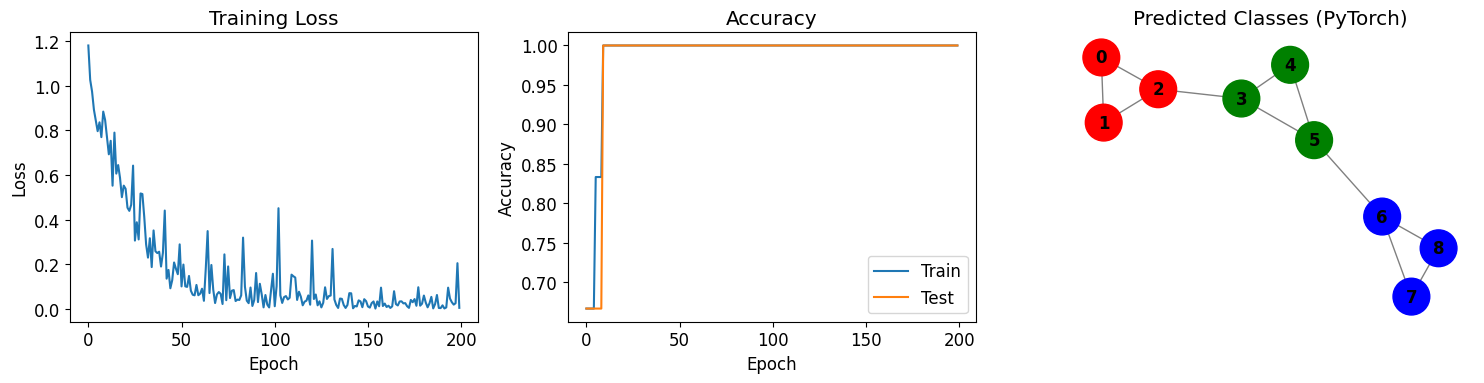


✅ Final Test Accuracy: 1.00


In [17]:
def train_gcn_pytorch():
    """
    Train GCN on a simple node classification task using PyTorch.
    """
    torch.manual_seed(42)

    # Create the same graph as before
    edges = [
        (0, 1), (1, 2), (0, 2),  # Community 1
        (3, 4), (4, 5), (3, 5),  # Community 2
        (6, 7), (7, 8), (6, 8),  # Community 3
        (2, 3), (5, 6)           # Cross-community
    ]

    n_nodes = 9
    n_features = 4
    n_classes = 3

    # Node features
    X = torch.randn(n_nodes, n_features) * 0.5
    X[0:3, 0] += 1
    X[3:6, 1] += 1
    X[6:9, 2] += 1

    # Labels
    y = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2])

    # Adjacency matrix
    A = torch.zeros(n_nodes, n_nodes)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1

    A_hat = compute_normalized_adjacency_torch(A)

    # Train/test split
    train_mask = torch.tensor([False, True, True, False, True, True, False, True, True])
    test_mask = ~train_mask

    # Create model
    model = GCN(in_features=n_features, hidden_features=16, out_features=n_classes,
                num_layers=2, dropout=0.5)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Training
    losses = []
    train_accs = []
    test_accs = []

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        output = model(X, A_hat)

        # Loss (only on training nodes)
        loss = F.cross_entropy(output[train_mask], y[train_mask])

        # Backward pass
        loss.backward()
        optimizer.step()

        # Evaluation
        model.eval()
        with torch.no_grad():
            output = model(X, A_hat)
            preds = output.argmax(dim=1)
            train_acc = (preds[train_mask] == y[train_mask]).float().mean().item()
            test_acc = (preds[test_mask] == y[test_mask]).float().mean().item()

        losses.append(loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 50 == 0:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | "
                  f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(losses)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')

    axes[1].plot(train_accs, label='Train')
    axes[1].plot(test_accs, label='Test')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    # Visualize
    G = nx.Graph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)

    model.eval()
    with torch.no_grad():
        final_output = model(X, A_hat)
        final_preds = final_output.argmax(dim=1).numpy()

    colors = ['red', 'green', 'blue']
    node_colors = [colors[p] for p in final_preds]

    nx.draw(G, pos, ax=axes[2], node_color=node_colors, with_labels=True,
            node_size=700, font_size=12, font_weight='bold', edge_color='gray')
    axes[2].set_title('Predicted Classes (PyTorch)')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Final Test Accuracy: {test_accs[-1]:.2f}")

train_gcn_pytorch()

---

# Chapter 7: Node Classification on Real Data 🎯

---

Let's apply our GCN to a real dataset: the **Karate Club** network - a famous social network of 34 members of a karate club documented by Wayne Zachary in 1977.

📊 Karate Club Network
   Nodes: 34
   Edges: 78
   Training nodes: 6 (17.6%)
   Test nodes: 28 (82.4%)

✅ Final Test Accuracy: 96.43%


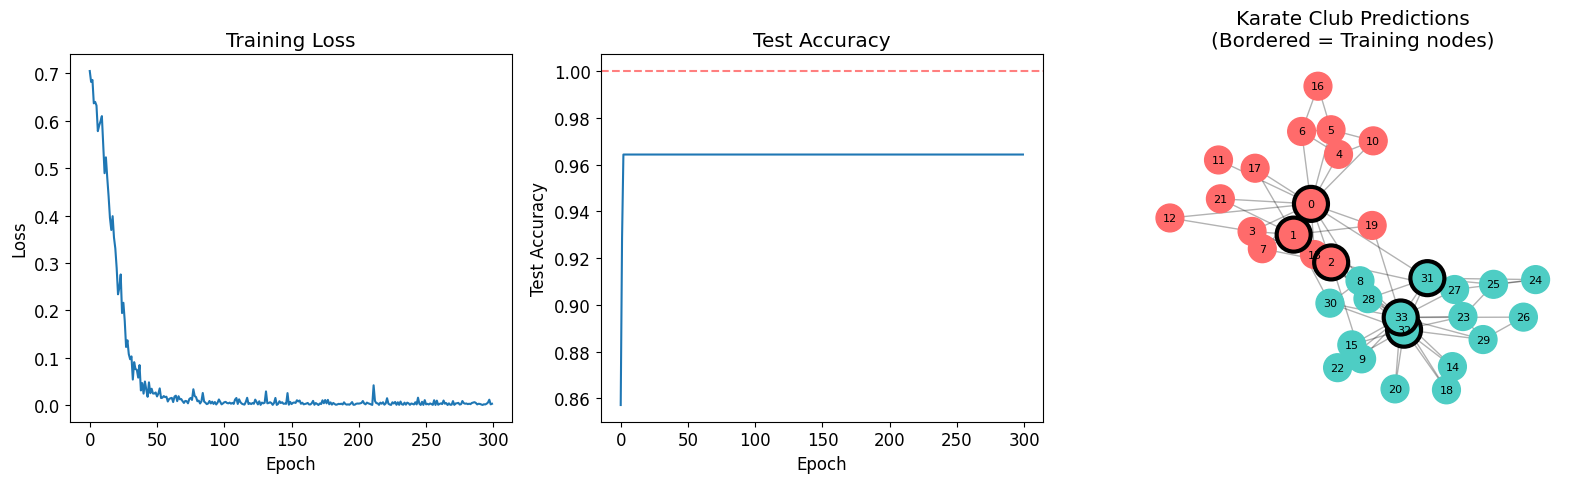


📈 Results:
   Correct: 33/34
   Misclassified nodes: [8]


In [18]:
def karate_club_demo():
    """
    Node classification on Zachary's Karate Club network.
    """
    torch.manual_seed(42)

    # Load Karate Club
    G = nx.karate_club_graph()
    n_nodes = G.number_of_nodes()

    print(f"📊 Karate Club Network")
    print(f"   Nodes: {n_nodes}")
    print(f"   Edges: {G.number_of_edges()}")

    # Get ground truth communities (the club split into 2 groups)
    labels = []
    for node in G.nodes():
        if G.nodes[node]['club'] == 'Mr. Hi':
            labels.append(0)
        else:
            labels.append(1)
    y = torch.tensor(labels)

    # Create adjacency matrix
    A = torch.tensor(nx.adjacency_matrix(G).toarray(), dtype=torch.float)
    A_hat = compute_normalized_adjacency_torch(A)

    # Node features: use one-hot encoding of node ID
    X = torch.eye(n_nodes)

    # Train/test split: use only a few labeled nodes per class
    train_nodes = [0, 1, 2, 32, 33, 31]  # Some from each class
    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    train_mask[train_nodes] = True
    test_mask = ~train_mask

    print(f"   Training nodes: {sum(train_mask)} ({100*sum(train_mask)/n_nodes:.1f}%)")
    print(f"   Test nodes: {sum(test_mask)} ({100*sum(test_mask)/n_nodes:.1f}%)")

    # Create model
    model = GCN(in_features=n_nodes, hidden_features=16, out_features=2,
                num_layers=2, dropout=0.5)

    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Training
    losses = []
    test_accs = []

    for epoch in range(300):
        model.train()
        optimizer.zero_grad()

        output = model(X, A_hat)
        loss = F.cross_entropy(output[train_mask], y[train_mask])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            output = model(X, A_hat)
            preds = output.argmax(dim=1)
            test_acc = (preds[test_mask] == y[test_mask]).float().mean().item()

        losses.append(loss.item())
        test_accs.append(test_acc)

    print(f"\n✅ Final Test Accuracy: {test_accs[-1]:.2%}")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Training curves
    axes[0].plot(losses)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')

    axes[1].plot(test_accs)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title('Test Accuracy')
    axes[1].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

    # Network visualization
    pos = nx.spring_layout(G, seed=42)

    model.eval()
    with torch.no_grad():
        final_preds = model(X, A_hat).argmax(dim=1).numpy()

    # Color by prediction, shape indicates train/test
    colors = ['#FF6B6B' if p == 0 else '#4ECDC4' for p in final_preds]

    # Draw test nodes
    test_nodes = [i for i in range(n_nodes) if test_mask[i]]
    nx.draw_networkx_nodes(G, pos, nodelist=test_nodes, node_color=[colors[i] for i in test_nodes],
                          node_size=400, ax=axes[2])

    # Draw train nodes with border
    train_nodes_list = [i for i in range(n_nodes) if train_mask[i]]
    nx.draw_networkx_nodes(G, pos, nodelist=train_nodes_list, node_color=[colors[i] for i in train_nodes_list],
                          node_size=600, edgecolors='black', linewidths=3, ax=axes[2])

    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=axes[2])
    nx.draw_networkx_labels(G, pos, font_size=8, ax=axes[2])

    axes[2].set_title('Karate Club Predictions\n(Bordered = Training nodes)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Show confusion
    correct = (final_preds == y.numpy())
    print(f"\n📈 Results:")
    print(f"   Correct: {sum(correct)}/{n_nodes}")
    incorrect_nodes = [i for i in range(n_nodes) if not correct[i]]
    if incorrect_nodes:
        print(f"   Misclassified nodes: {incorrect_nodes}")
    else:
        print(f"   All nodes correctly classified! 🎉")

karate_club_demo()

---

# 📝 Summary & Key Takeaways

---

## What We Learned

### 1. Graphs Are Universal
- Graphs represent relationships: social networks, molecules, knowledge bases
- Nodes have features, edges represent connections

### 2. Graph Representations
| Representation | Best For | Complexity |
|----------------|----------|------------|
| Adjacency Matrix | Dense graphs, math operations | O(n²) space |
| Edge List | Storage, sparse graphs | O(E) space |
| Adjacency List | Neighbor lookup | O(n + E) space |
| COO Format | Deep learning frameworks | O(2E) space |

### 3. Message Passing
```
For each layer:
  1. AGGREGATE: Collect neighbor information
  2. UPDATE: Combine with own features
  3. Transform: Apply learnable weights
```

### 4. GCN Formula
$$H^{(l+1)} = \sigma\left( \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)} \right)$$

Key components:
- Self-loops: $\tilde{A} = A + I$
- Symmetric normalization: prevents feature explosion
- Learnable weights: $W^{(l)}$

---

## 🚀 What's Next?

In **Part 2: Modern GNN Architectures**, we'll explore:
- **GraphSAGE**: Sampling-based approach for large graphs
- **GAT**: Attention mechanisms for graphs
- **GIN**: Maximally expressive GNNs
- **Graph Pooling**: For graph-level tasks
- **PyTorch Geometric**: Industry-standard GNN library

---

## 📚 Quick Reference

```python
# NumPy GCN Layer
def gcn_layer(H, A_hat, W, b):
    return relu(A_hat @ H @ W + b)

# Normalized Adjacency
def normalize_adj(A):
    A_tilde = A + np.eye(n)  # Add self-loops
    D_inv_sqrt = np.diag(1/np.sqrt(A_tilde.sum(1)))
    return D_inv_sqrt @ A_tilde @ D_inv_sqrt

# PyTorch GCN
class GCNLayer(nn.Module):
    def forward(self, H, A_hat):
        return A_hat @ H @ self.weight + self.bias
```

---

**Congratulations!** 🎉 You now understand the fundamentals of Graph Neural Networks!

Continue to **Part 2** to learn about modern architectures and PyTorch Geometric.